In [1]:
# Library Imports & Version Check

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow import keras
import cv2

print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")
print(f"pillow     : {Image.__version__}")
print(f"tensorflow : {tf.__version__}")
print(f"keras      : {keras.__version__}")
print(f"opencv     : {cv2.__version__}")

numpy      : 2.4.1
matplotlib : 3.10.9
seaborn    : 0.13.2
pillow     : 12.2.0
tensorflow : 2.21.0
keras      : 3.14.1
opencv     : 4.13.0


In [3]:
# Project Paths Setup

In [4]:
from pathlib import Path

BASE_DIR = Path(r"C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection")

RAW_OUT     = BASE_DIR / "data" / "raw" / "out"
RAW_NOT_OUT = BASE_DIR / "data" / "raw" / "not_out"

AUG_OUT     = BASE_DIR / "data" / "data_augmented" / "out"
AUG_NOT_OUT = BASE_DIR / "data" / "data_augmented" / "not_out"

SPLIT_TRAIN = BASE_DIR / "data" / "split" / "train"
SPLIT_VAL   = BASE_DIR / "data" / "split" / "val"
SPLIT_TEST  = BASE_DIR / "data" / "split" / "test"

MODELS_DIR  = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

for p in [RAW_OUT, RAW_NOT_OUT, AUG_OUT, AUG_NOT_OUT,
          SPLIT_TRAIN, SPLIT_VAL, SPLIT_TEST, MODELS_DIR, RESULTS_DIR]:
    print(f"{'OK' if p.exists() else 'MISSING'} → {p}")

OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\raw\out
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\raw\not_out
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\data_augmented\out
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\data_augmented\not_out
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\split\train
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\split\val
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\split\test
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models
OK → C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\results


In [5]:
# Raw Image Counts

In [6]:
out_count     = len(list(RAW_OUT.glob("*.*")))
not_out_count = len(list(RAW_NOT_OUT.glob("*.*")))

print(f"out     : {out_count} images")
print(f"not_out : {not_out_count} images")
print(f"total   : {out_count + not_out_count} images")

out     : 127 images
not_out : 98 images
total   : 225 images


In [7]:
# Sample Images Visualisation

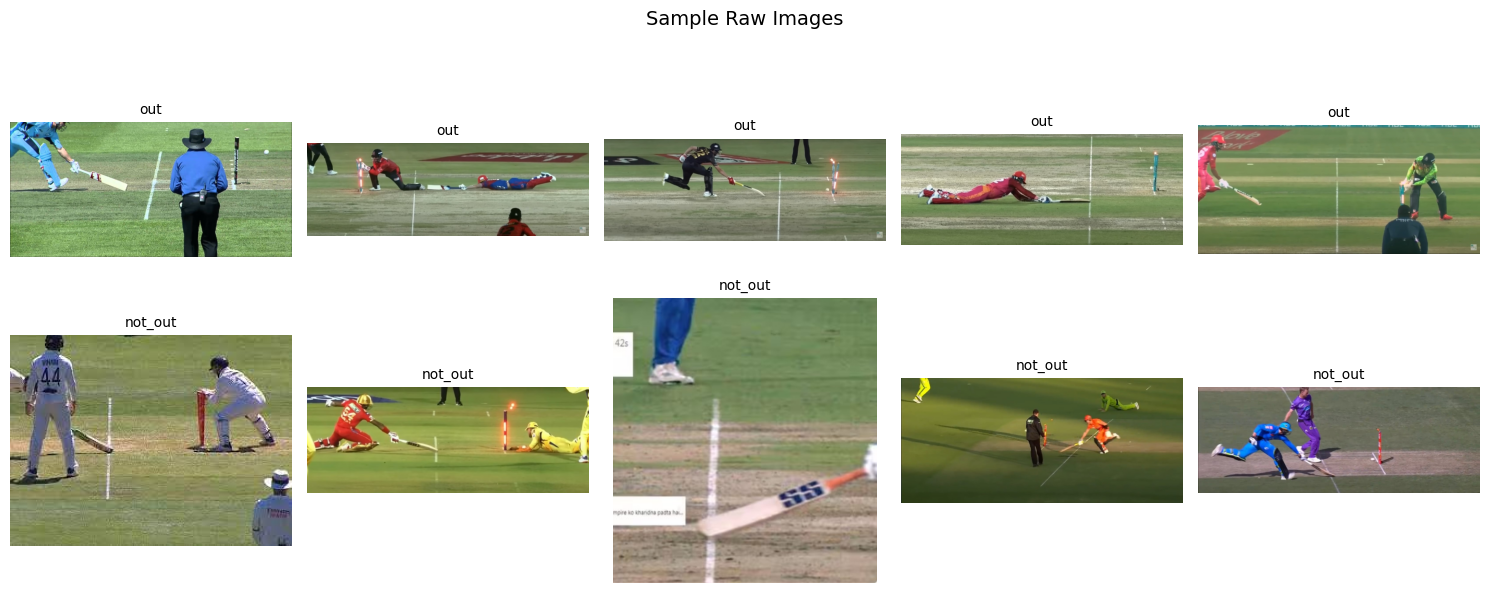

In [8]:
out_samples     = list(RAW_OUT.glob("*.*"))[:5]
not_out_samples = list(RAW_NOT_OUT.glob("*.*"))[:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx, img_path in enumerate(out_samples):
    img = mpimg.imread(img_path)
    axes[0, idx].imshow(img)
    axes[0, idx].set_title("out", fontsize=10)
    axes[0, idx].axis("off")

for idx, img_path in enumerate(not_out_samples):
    img = mpimg.imread(img_path)
    axes[1, idx].imshow(img)
    axes[1, idx].set_title("not_out", fontsize=10)
    axes[1, idx].axis("off")

plt.suptitle("Sample Raw Images", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Class Distribution - Raw Images

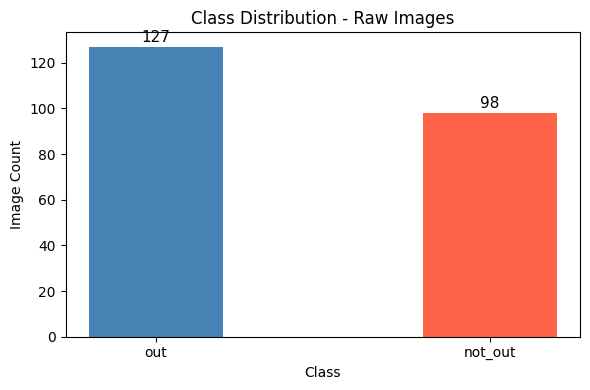

In [10]:
classes = ["out", "not_out"]
counts  = [len(list(RAW_OUT.glob("*.*"))), len(list(RAW_NOT_OUT.glob("*.*")))]

plt.figure(figsize=(6, 4))
bars = plt.bar(classes, counts, color=["steelblue", "tomato"], width=0.4)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(count), ha="center", va="bottom", fontsize=11)

plt.title("Class Distribution - Raw Images")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "raw_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Augmentation Types Visualisation

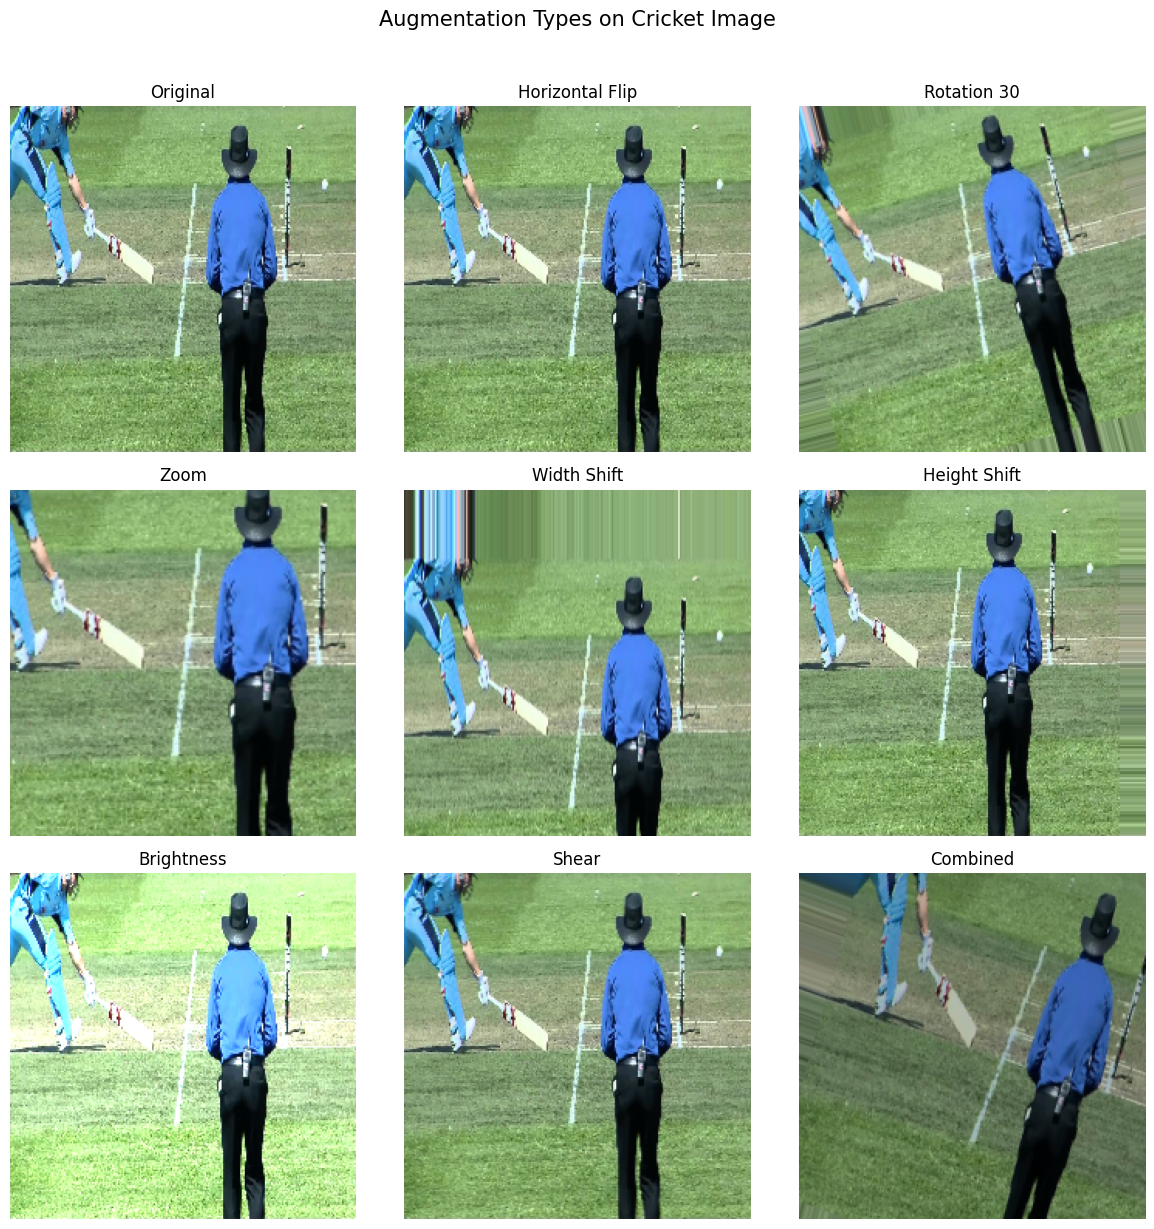

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

sample_path = list(RAW_OUT.glob("*.*"))[0]

img = load_img(sample_path, target_size=(224, 224))
img_array = img_to_array(img).reshape((1, 224, 224, 3))

augmentations = {
    "Original"        : ImageDataGenerator(rescale=1./255),
    "Horizontal Flip" : ImageDataGenerator(rescale=1./255, horizontal_flip=True),
    "Rotation 30"     : ImageDataGenerator(rescale=1./255, rotation_range=30),
    "Zoom"            : ImageDataGenerator(rescale=1./255, zoom_range=0.3),
    "Width Shift"     : ImageDataGenerator(rescale=1./255, width_shift_range=0.3),
    "Height Shift"    : ImageDataGenerator(rescale=1./255, height_shift_range=0.3),
    "Brightness"      : ImageDataGenerator(rescale=1./255, brightness_range=[0.5, 1.5]),
    "Shear"           : ImageDataGenerator(rescale=1./255, shear_range=0.3),
    "Combined"        : ImageDataGenerator(rescale=1./255, rotation_range=20,
                            width_shift_range=0.15, height_shift_range=0.15,
                            horizontal_flip=True, zoom_range=0.2,
                            shear_range=0.15, brightness_range=[0.7, 1.3]),
}

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, (name, datagen) in enumerate(augmentations.items()):
    aug_img = next(datagen.flow(img_array, batch_size=1))[0]
    axes[idx].imshow(aug_img)
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis("off")

plt.suptitle("Augmentation Types on Cricket Image", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_types.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Image Count After Augmentation

In [13]:
aug_out_count     = len(list(AUG_OUT.glob("*.*")))
aug_not_out_count = len(list(AUG_NOT_OUT.glob("*.*")))

raw_out_count     = len(list(RAW_OUT.glob("*.*")))
raw_not_out_count = len(list(RAW_NOT_OUT.glob("*.*")))

print(f"raw out             : {raw_out_count} images")
print(f"raw not_out         : {raw_not_out_count} images")
print(f"raw total           : {raw_out_count + raw_not_out_count} images")
print()
print(f"augmented out       : {aug_out_count} images")
print(f"augmented not_out   : {aug_not_out_count} images")
print(f"augmented total     : {aug_out_count + aug_not_out_count} images")
print()
print(f"new aug out         : {aug_out_count - raw_out_count} images")
print(f"new aug not_out     : {aug_not_out_count - raw_not_out_count} images")

raw out             : 127 images
raw not_out         : 98 images
raw total           : 225 images

augmented out       : 900 images
augmented not_out   : 900 images
augmented total     : 1800 images

new aug out         : 773 images
new aug not_out     : 802 images


In [14]:
# Class Distribution After Augmentation

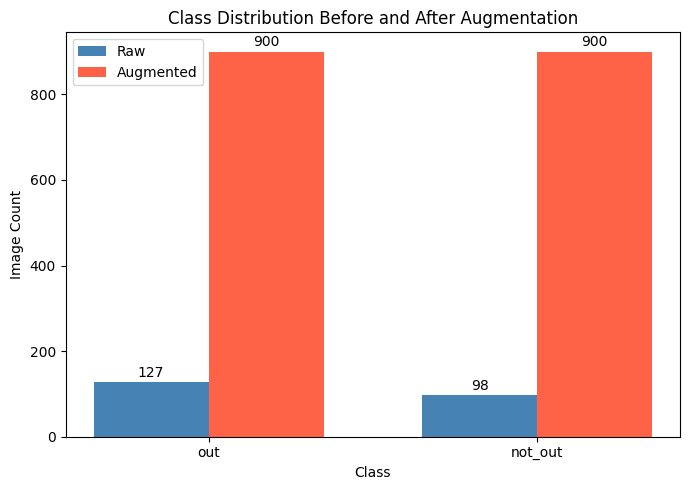

In [15]:
categories  = ["out", "not_out"]
raw_counts  = [len(list(RAW_OUT.glob("*.*"))), len(list(RAW_NOT_OUT.glob("*.*")))]
aug_counts  = [len(list(AUG_OUT.glob("*.*"))), len(list(AUG_NOT_OUT.glob("*.*")))]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, raw_counts, width, label="Raw",       color="steelblue")
bars2 = ax.bar(x + width/2, aug_counts, width, label="Augmented", color="tomato")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

ax.set_title("Class Distribution Before and After Augmentation")
ax.set_xlabel("Class")
ax.set_ylabel("Image Count")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Train / Val / Test Split Counts

In [17]:
for split_name, split_path in [("train", SPLIT_TRAIN), ("val", SPLIT_VAL), ("test", SPLIT_TEST)]:
    out_count     = len(list((split_path / "out").glob("*.*")))
    not_out_count = len(list((split_path / "not_out").glob("*.*")))
    total         = out_count + not_out_count
    print(f"{split_name:<6} → out: {out_count}  not_out: {not_out_count}  total: {total}")

train  → out: 630  not_out: 630  total: 1260
val    → out: 135  not_out: 135  total: 270
test   → out: 135  not_out: 135  total: 270


In [18]:
# Final Split Distribution Bar Chart

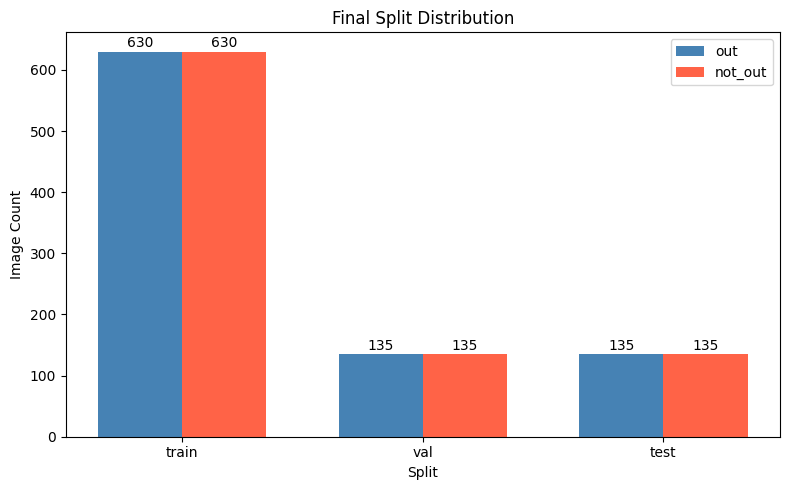

In [19]:
splits     = ["train", "val", "test"]
out_counts     = [len(list((SPLIT_TRAIN / "out").glob("*.*"))),
                  len(list((SPLIT_VAL   / "out").glob("*.*"))),
                  len(list((SPLIT_TEST  / "out").glob("*.*")))]
not_out_counts = [len(list((SPLIT_TRAIN / "not_out").glob("*.*"))),
                  len(list((SPLIT_VAL   / "not_out").glob("*.*"))),
                  len(list((SPLIT_TEST  / "not_out").glob("*.*")))]

x     = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, out_counts,     width, label="out",     color="steelblue")
bars2 = ax.bar(x + width/2, not_out_counts, width, label="not_out", color="tomato")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

ax.set_title("Final Split Distribution")
ax.set_xlabel("Split")
ax.set_ylabel("Image Count")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()